We build the XOR problem: <br>EXACT TASK THAT CAUSED THE WINTER - SOLVED FROM SCRATCH WITH NUMPY, NO FRAMEWORKS.<br>
	- FOUR DATA POINTS <br>
	- TINY NETWORK <br>
	- COMPLETE VISIBILITY

In [1]:
import numpy as np

X = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]])

y = np.array([[0], [1], [1], [0]]) #XOR: 1 if inputs differ

### Build stage 1: the forward pass

In [2]:
rng = np.random.default_rng(42)

W1 = rng.normal(0,1, (2, 2)) # input - hidden weights
b1 = np.zeros((1, 2)) #hidden biases
W2 = rng.normal(0,1, (2,1)) #hidden -output weights
b2 = np.zeros((1,1)) #output bias

def sigmoid(z):
    return 1/ (1 + np.exp(-z))

def forward(X):
    hidden = sigmoid(X @ W1 + b1)   #Each hidden neuron: a logistic regression
    output = sigmoid(hidden @ W2 + b2)  #A logistic regression ON the hidden verdicts
    return hidden, output

hidden, output = forward(X)
print(output)

[[0.16429565]
 [0.09433316]
 [0.1879975 ]
 [0.11244935]]


### Build stage 2: loss + backprop

In [3]:
lr =  0.5 # learning rate

losses = []
for epoch in range(10000):
    #forward
    hidden, output = forward(X)

    #loss
    loss = np.mean((output -y) ** 2)
    losses.append(loss)

    #backward - chain rule, output layer first
    d_output = (output -y) * output * (1-output) #blame at output
    d_W2 = hidden.T @ d_output
    d_b2 = d_output.sum(axis=0, keepdims=True)

    d_hidden = (d_output @ W2.T) * hidden * (1 - hidden) # blame passed back
    d_W1 = X.T @ d_hidden
    d_b1 = d_hidden.sum(axis=0, keepdims=True)

    #descend
    W2 -= lr * d_W2; b2 -= lr * d_b2
    W1 -= lr * d_W1; b1 -= lr * d_b1

print(forward(X)[1].round(3))

[[0.022]
 [0.975]
 [0.975]
 [0.02 ]]


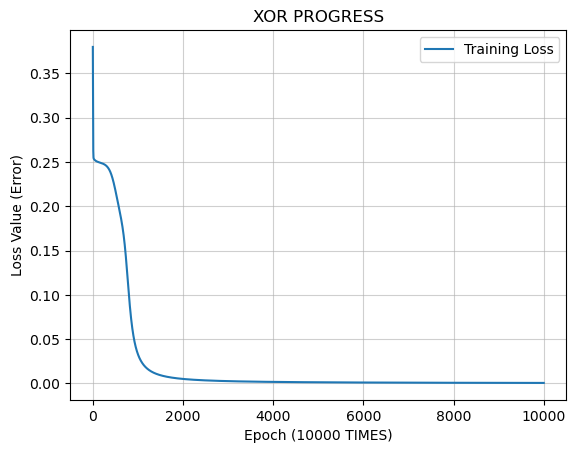

In [10]:
import matplotlib.pyplot as plt

plt.plot(losses, label="Training Loss")
plt.title('XOR PROGRESS')
plt.xlabel('Epoch (10000 TIMES)')
plt.ylabel('Loss Value (Error)')
plt.grid(True, alpha=0.6)
plt.legend()
plt.show()

In [18]:
import pandas as pd
import numpy as np

print(f"Weight 1: {W1}")
print(f"Bias 1: {b1}")

Weight 1: [[ 6.52585475 -6.83493794]
 [-6.28701822  6.96789188]]
Bias 1: [[3.16844603 3.4827622 ]]


In [ ]:
# Four corners as the hidden layer sees them.
print(forward(X)[0].round(2))

[[0.96 0.97]
 [0.04 1.  ]
 [1.   0.03]
 [0.97 0.97]]
